# Violent Crime Capstone

This notebook:
- Compares education and unemployment and all types of violent crime
- Imports and cleans population data, calculates crime rate and compares all types of violent crime again
- Performs additional cleaning and saves dataset as "capstone_data_20260414_Wendy.csv"

## 1. Education vs. Unemployment

In [1]:
import pandas as pd

df = pd.read_csv("violent_crime_final_dataset.csv")
df.head()

,state,metropolitan_nonmetropolitan,county,violent_crime,murder_and_nonnegligent_manslaughter,rape,robbery,aggravated_assault,property_crime,burglary,...,county_clean,fips,county_name,labor_force,employed,unemployed,unemployment_rate,median_household_income,poverty_rate,bachelors_or_higher_pct
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,...,AUTAUGA,1001,"Autauga County, AL",28467.0,27702.0,765.0,2.7,72481.0,11.3,29.1
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,...,BALDWIN,1003,"Baldwin County, AL",116653.0,113448.0,3205.0,2.7,78775.0,10.1,33.7
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,...,BIBB,1007,"Bibb County, AL",8710.0,8446.0,264.0,3.0,52541.0,22.5,11.7
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,...,BLOUNT,1009,"Blount County, AL",26922.0,26204.0,718.0,2.7,64190.0,12.9,15.8
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,...,CALHOUN,1015,"Calhoun County, AL",49605.0,47995.0,1610.0,3.2,55029.0,17.9,20.6


In [2]:
print(df.columns.tolist())

['state', 'metropolitan_nonmetropolitan', 'county', 'violent_crime', 'murder_and_nonnegligent_manslaughter', 'rape', 'robbery', 'aggravated_assault', 'property_crime', 'burglary', 'larceny_theft', 'motor_vehicle_theft', 'arson', 'year', 'state_abbr', 'county_clean', 'fips', 'county_name', 'labor_force', 'employed', 'unemployed', 'unemployment_rate', 'median_household_income', 'poverty_rate', 'bachelors_or_higher_pct']


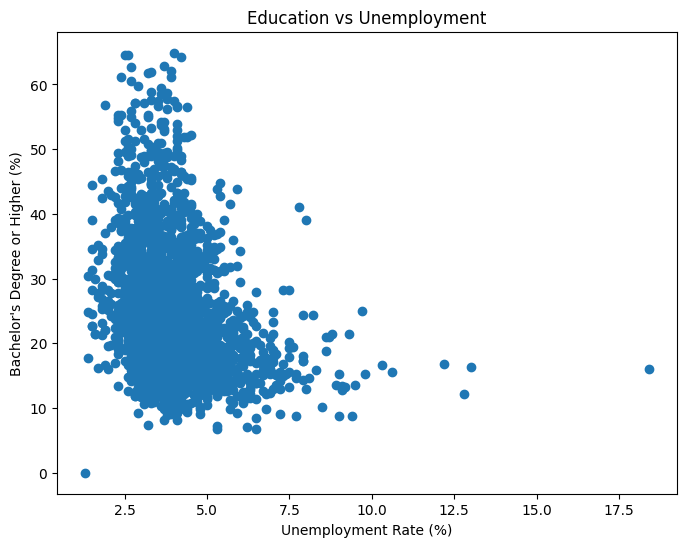

In [3]:
import matplotlib.pyplot as plt

x = "unemployment_rate"
y = "bachelors_or_higher_pct"

plt.figure(figsize=(8, 6))
plt.scatter(df[x], df[y])
plt.xlabel(x)
plt.ylabel(y)
plt.title(f"{x} vs {y}")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Bachelor's Degree or Higher (%)")
plt.title("Education vs Unemployment")
plt.show()

In [4]:
df[["unemployment_rate", "bachelors_or_higher_pct"]].corr()

,unemployment_rate,bachelors_or_higher_pct
unemployment_rate,1.000000,-0.303266
bachelors_or_higher_pct,-0.303266,1.000000


In [5]:
import sys
!{sys.executable} -m pip install seaborn

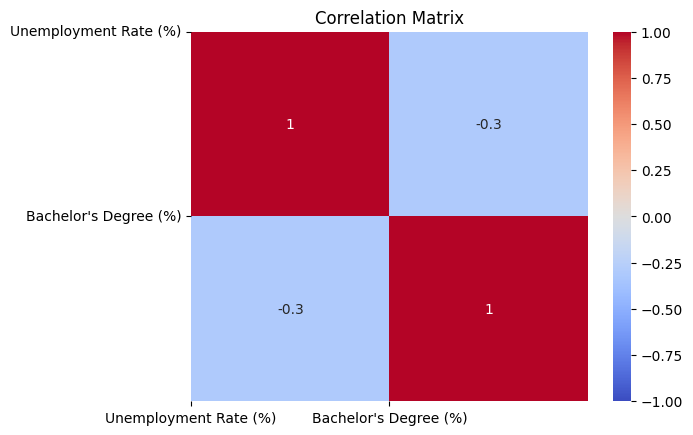

In [7]:
import seaborn as sns

corr = df[["unemployment_rate", "bachelors_or_higher_pct"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

labels = ["Unemployment Rate (%)", "Bachelor's Degree (%)"]

plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0, ha="center")
plt.yticks(ticks=range(len(labels)), labels=labels, rotation=0, va="center")

plt.title("Correlation Matrix")

plt.show()

## 2. All Types of Violent Crime vs. Unemployment, Poverty, and Education


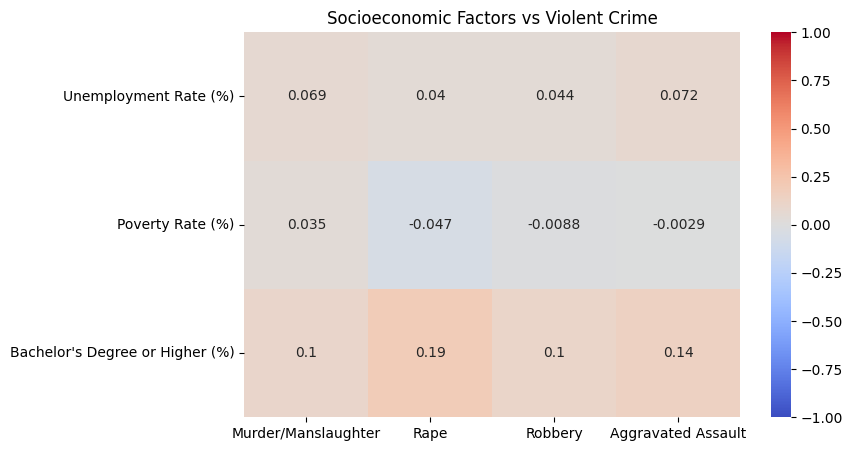

In [8]:
predictors = [
    "unemployment_rate",
    "poverty_rate",
    "bachelors_or_higher_pct"
]

crimes = [
    "murder_and_nonnegligent_manslaughter",
    "rape",
    "robbery",
    "aggravated_assault"
]

corr = df[predictors + crimes].corr()

subset = corr.loc[predictors, crimes]

subset_plot = subset.copy()

subset_plot.columns = [
    "Murder/Manslaughter",
    "Rape",
    "Robbery",
    "Aggravated Assault"
]

subset_plot.index = [
    "Unemployment Rate (%)",
    "Poverty Rate (%)",
    "Bachelor's Degree or Higher (%)"
]

plt.figure(figsize=(8, 5))

sns.heatmap(
    subset_plot,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.title("Socioeconomic Factors vs Violent Crime")

plt.show()

## 3. Import, Clean, and Merge Census Data (Population)

In [9]:
import pandas as pd

pop = pd.read_csv("Census_ACS_2024_5-Yr_Estimate.csv.csv", skiprows=[1])

pop.head()

,GEO_ID,NAME,B01003_001E,B01003_001M,Unnamed: 4
0,0500000US01001,"Autauga County, Alabama",59947,*****,NaN
1,0500000US01003,"Baldwin County, Alabama",246989,*****,NaN
2,0500000US01005,"Barbour County, Alabama",24643,*****,NaN
3,0500000US01007,"Bibb County, Alabama",22130,*****,NaN
4,0500000US01009,"Blount County, Alabama",59518,*****,NaN


In [10]:
print(pop.columns.tolist())

['GEO_ID', 'NAME', 'B01003_001E', 'B01003_001M', 'Unnamed: 4']


In [11]:
# clean the census data, get the fips from the GEO_ID
pop = pop[["GEO_ID", "NAME", "B01003_001E"]].copy()
pop = pop.rename(columns={"B01003_001E": "population"})
pop["fips"] = pop["GEO_ID"].str[-5:]


In [12]:
pop["population"] = pd.to_numeric(pop["population"], errors="coerce")

In [13]:
print(pop.columns.tolist())

['GEO_ID', 'NAME', 'population', 'fips']


In [14]:
pop.head()
pop.dtypes

GEO_ID          str
NAME            str
population    int64
fips            str
dtype: object

In [15]:
df.dtypes

state                                       str
metropolitan_nonmetropolitan                str
county                                      str
violent_crime                             int64
murder_and_nonnegligent_manslaughter      int64
rape                                      int64
robbery                                   int64
aggravated_assault                        int64
property_crime                            int64
burglary                                  int64
larceny_theft                             int64
motor_vehicle_theft                       int64
arson                                     int64
year                                      int64
state_abbr                                  str
county_clean                                str
fips                                      int64
county_name                                 str
labor_force                             float64
employed                                float64
unemployed                              

In [16]:
# format fips
df["fips"] = df["fips"].astype(str).str.zfill(5)
pop["fips"] = pop["fips"].astype(str).str.zfill(5)

In [17]:
# merge
df = df.merge(pop[["fips", "population"]], on="fips", how="left")

In [18]:
df["population"].isna().sum()

np.int64(0)

## 4. Calculate the Crime Rate based on the Population

In [19]:
# calculate crime rates
crime_cols = [
    "violent_crime",
    "murder_and_nonnegligent_manslaughter",
    "rape",
    "robbery",
    "aggravated_assault"
]

for col in crime_cols:
    df[col + "_rate"] = (df[col] / df["population"]) * 100000

In [20]:
df[[col for col in df.columns if col.endswith("_rate")]].head()

,unemployment_rate,poverty_rate,violent_crime_rate,murder_and_nonnegligent_manslaughter_rate,rape_rate,robbery_rate,aggravated_assault_rate
0,2.7,11.3,90.079570,1.668140,11.676981,0.000000,76.734449
1,2.7,10.1,55.468057,0.000000,1.619505,0.000000,53.848552
2,3.0,22.5,153.637596,0.000000,22.593764,0.000000,131.043832
3,2.7,12.9,137.773447,1.680164,30.242952,3.360328,102.490003
4,3.2,17.9,205.013352,1.722801,4.307003,0.000000,198.983547


## 5. Updated Correlation based on Crime Rate

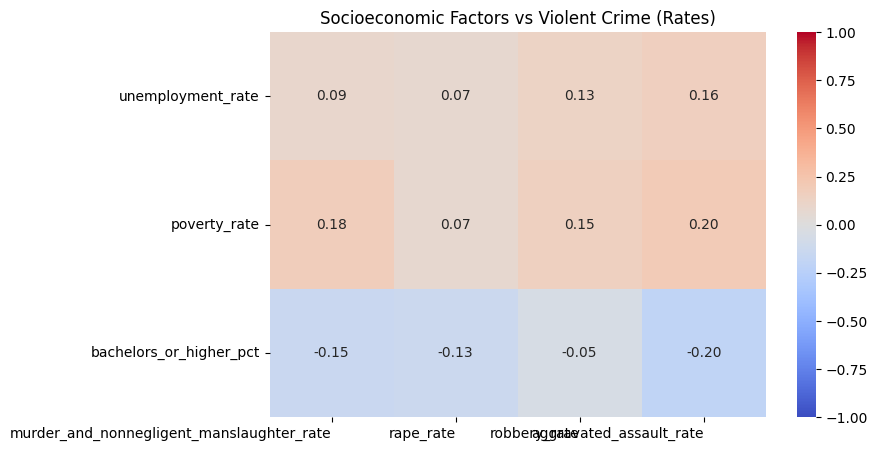

In [21]:
# updated heat map with crime rates
import seaborn as sns
import matplotlib.pyplot as plt

predictors = [
    "unemployment_rate",
    "poverty_rate",
    "bachelors_or_higher_pct"
]

crime_rates = [
    "murder_and_nonnegligent_manslaughter_rate",
    "rape_rate",
    "robbery_rate",
    "aggravated_assault_rate"
]

corr = df[predictors + crime_rates].corr()
subset = corr.loc[predictors, crime_rates]

plt.figure(figsize=(8,5))

sns.heatmap(
    subset,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.xticks(rotation=30, ha="right")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.title("Socioeconomic Factors vs Violent Crime (Rates)")

plt.show()

## Additional Cleaning and Saving New Dataset

In [22]:
df.dtypes

state                                            str
metropolitan_nonmetropolitan                     str
county                                           str
violent_crime                                  int64
murder_and_nonnegligent_manslaughter           int64
rape                                           int64
robbery                                        int64
aggravated_assault                             int64
property_crime                                 int64
burglary                                       int64
larceny_theft                                  int64
motor_vehicle_theft                            int64
arson                                          int64
year                                           int64
state_abbr                                       str
county_clean                                     str
fips                                             str
county_name                                      str
labor_force                                  f

In [23]:
df_clean = df.rename(columns={
    "violent_crime": "violent_crime_count",
    "murder_and_nonnegligent_manslaughter": "murder_and_nonnegligent_manslaughter_count",
    "rape": "rape_count",
    "robbery": "robbery_count",
    "aggravated_assault": "aggravated_assault_count",

    "violent_crime_rate": "violent_crime_rate_per_100k",
    "murder_and_nonnegligent_manslaughter_rate": "murder_and_nonnegligent_manslaughter_rate",
    "rape_rate": "rape_rate",
    "robbery_rate": "robbery_rate",
    "aggravated_assault_rate": "aggravated_assault_rate",

    "unemployment_rate": "unemployment_pct",
    "poverty_rate": "poverty_pct",
    "bachelors_or_higher_pct": "bachelors_or_higher_pct",

    "median_household_income": "median_income",

    "county_name": "county",
    "state_abbr": "state"
})

In [ ]:
df

In [24]:
label_map = {
    "violent_crime_count": "Violent Crime Count",
    "murder_and_nonnegligent_manslaughter_count": "Murder (Nonnegligent Manslaughter) Count",
    "rape_count": "Rape Count",
    "robbery_count": "Robbery Count",
    "aggravated_assault_count": "Aggravated Assault Count",

    "violent_crime_rate_per_100k": "Violent Crime Rate (per 100,000)",
    "murder_and_nonnegligent_manslaughter_rate": "Murder (Nonnegligent Manslaughter) Rate",
    "rape_rate": "Rape Rate",
    "robbery_rate": "Robbery Rate",
    "aggravated_assault_rate": "Aggravated Assault Rate",

    "unemployment_pct": "Unemployment Rate (%)",
    "poverty_pct": "Poverty Rate (%)",
    "bachelors_or_higher_pct": "Bachelor's Degree (%)",

    "median_income": "Median Household Income",

    "county": "County",
    "state": "State"
}

In [48]:
df_clean.head()
df_clean.columns.tolist()

['state',
 'metropolitan_nonmetropolitan',
 'county',
 'violent_crime_count',
 'murder_and_nonnegligent_manslaughter_count',
 'rape_count',
 'robbery_count',
 'aggravated_assault_count',
 'property_crime',
 'burglary',
 'larceny_theft',
 'motor_vehicle_theft',
 'arson',
 'year',
 'state',
 'county_clean',
 'fips',
 'county',
 'labor_force',
 'employed',
 'unemployed',
 'unemployment_pct',
 'median_income',
 'poverty_pct',
 'bachelors_or_higher_pct',
 'population',
 'violent_crime_rate_per_100k',
 'murder_and_nonnegligent_manslaughter_rate',
 'rape_rate',
 'robbery_rate',
 'aggravated_assault_rate']

In [49]:
df_clean.head()

,state,metropolitan_nonmetropolitan,county,violent_crime_count,murder_and_nonnegligent_manslaughter_count,rape_count,robbery_count,aggravated_assault_count,property_crime,burglary,...,unemployment_pct,median_income,poverty_pct,bachelors_or_higher_pct,population,violent_crime_rate_per_100k,murder_and_nonnegligent_manslaughter_rate,rape_rate,robbery_rate,aggravated_assault_rate
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,...,2.7,72481.0,11.3,29.1,59947,90.079570,1.668140,11.676981,0.000000,76.734449
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,...,2.7,78775.0,10.1,33.7,246989,55.468057,0.000000,1.619505,0.000000,53.848552
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,...,3.0,52541.0,22.5,11.7,22130,153.637596,0.000000,22.593764,0.000000,131.043832
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,...,2.7,64190.0,12.9,15.8,59518,137.773447,1.680164,30.242952,3.360328,102.490003
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,...,3.2,55029.0,17.9,20.6,116090,205.013352,1.722801,4.307003,0.000000,198.983547


In [50]:
df_clean.to_csv("capstone_data_20260414_Wendy.csv", index=False)